In [72]:
#import necessary packages
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_validate

from mlxtend.plotting import plot_confusion_matrix


## Exploratory Data Analysis

In [73]:
#read training data as pandas data frame
model_data=pd.read_csv('cwk_data.csv')
model_data.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,duration,campaign,pdays,previous,poutcome,y
0,42,technician,married,secondary,no,27,no,no,cellular,14,259,4,-1,0,unknown,no
1,28,services,single,secondary,no,230,yes,yes,cellular,17,181,2,-1,0,unknown,no
2,52,housemaid,divorced,tertiary,no,4306,no,no,cellular,22,107,2,-1,0,unknown,no
3,70,retired,married,tertiary,no,44,no,no,cellular,18,1104,2,88,2,other,yes
4,50,management,married,primary,no,313,no,no,telephone,14,958,1,-1,0,unknown,yes


In [59]:
# number of rows and columns in the dataset
model_data.shape

(4000, 16)

In [64]:
#name of all the columns in the dataset
model_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'poutcome', 'y'],
      dtype='object')

In [ ]:
#datatype of each column in the dataset
model_data.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [61]:
#Find if any null values exists
np.round(model_data.isnull().mean() * 100,1)

age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
duration     0.0
campaign     0.0
pdays        0.0
previous     0.0
poutcome     0.0
y            0.0
dtype: float64

### Count charts for each categorical columns

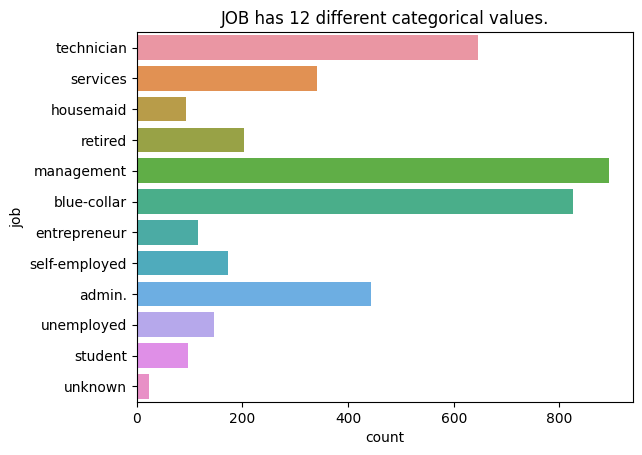

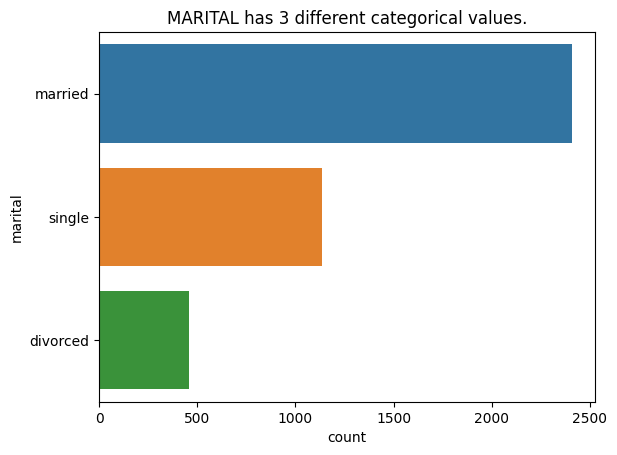

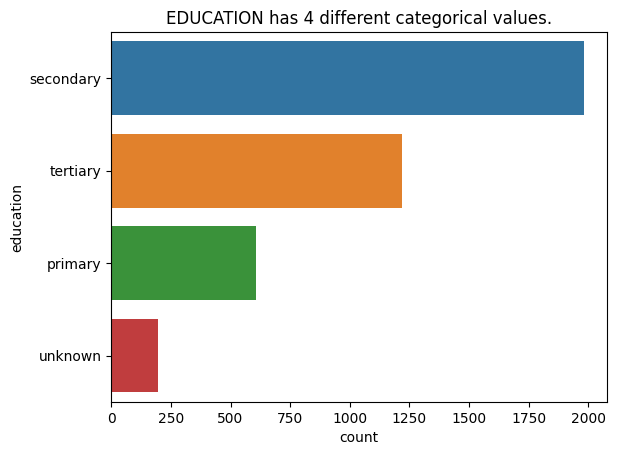

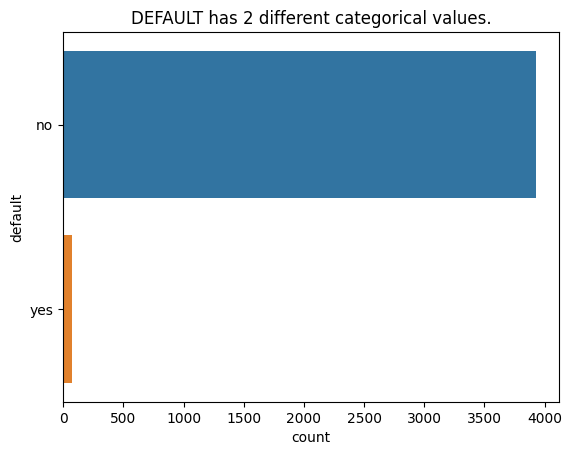

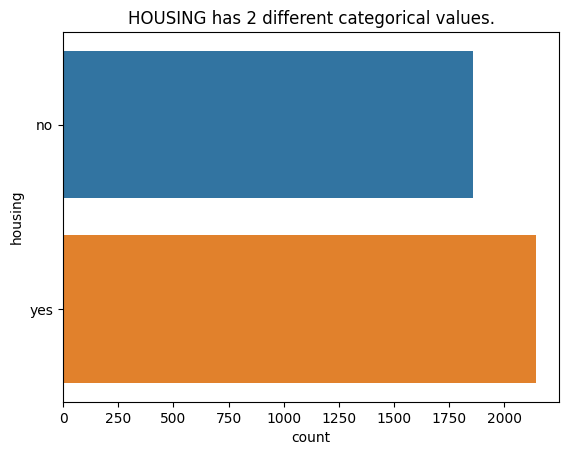

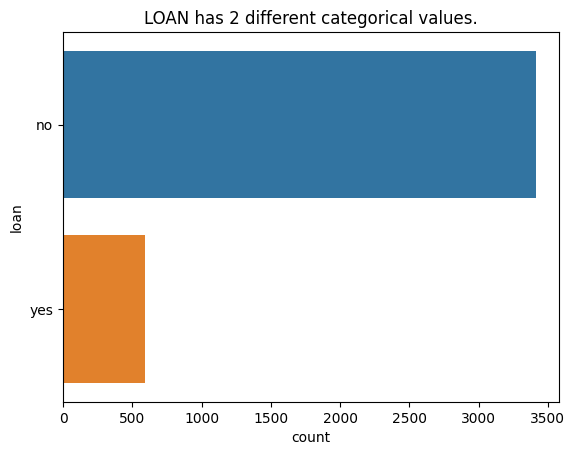

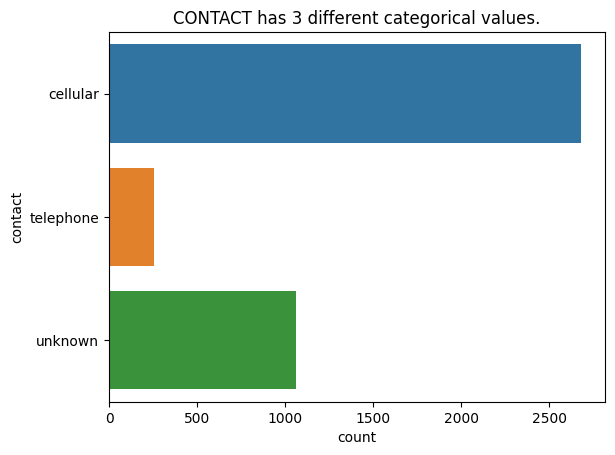

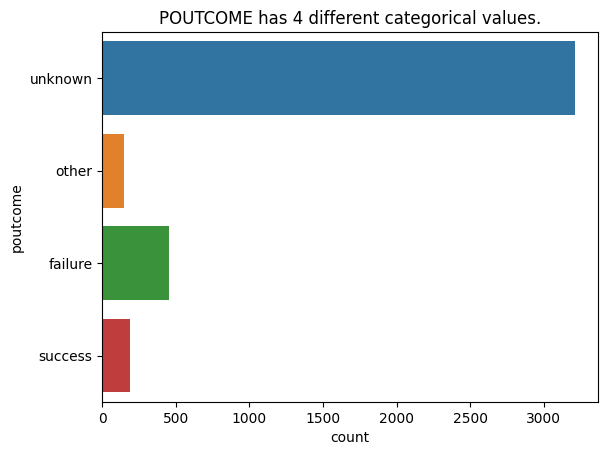

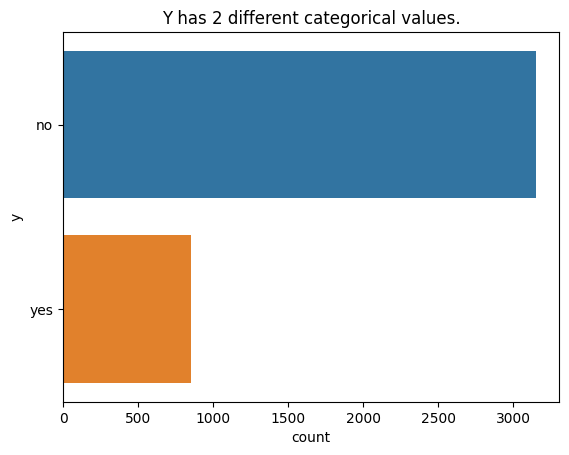

In [5]:
for col in model_data.select_dtypes('object').columns.to_list():
    plt.title("{} has {} different categorical values.".format(col.upper(),model_data[col].nunique()))
    sns.countplot(model_data,y=col)
    plt.show()

#### Our target class is highly imbalanced. This is addressed at later stage during model evaluation.

### Count charts for numerical datatype columns.

Min AGE is: 18
Max AGE is: 95
Mean AGE is: 41.0865
Standard deviation of AGE is: 10.77


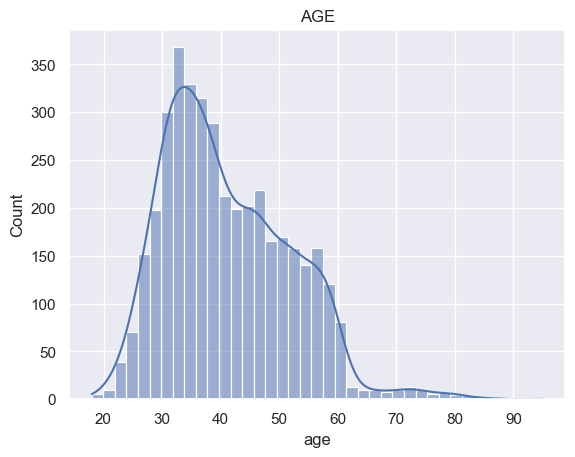

Min BALANCE is: -1884
Max BALANCE is: 42045
Mean BALANCE is: 1431.79625
Standard deviation of BALANCE is: 2935.48


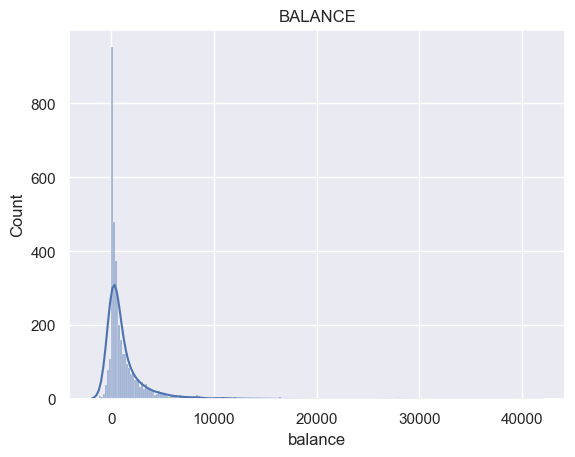

Min DAY is: 1
Max DAY is: 31
Mean DAY is: 15.642
Standard deviation of DAY is: 8.27


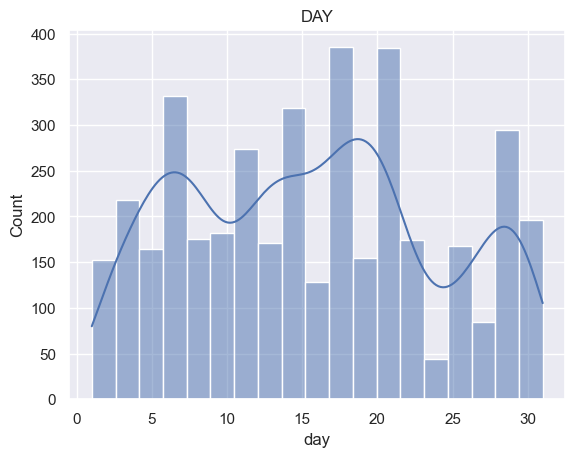

Min DURATION is: 5
Max DURATION is: 2516
Mean DURATION is: 288.96475
Standard deviation of DURATION is: 285.18


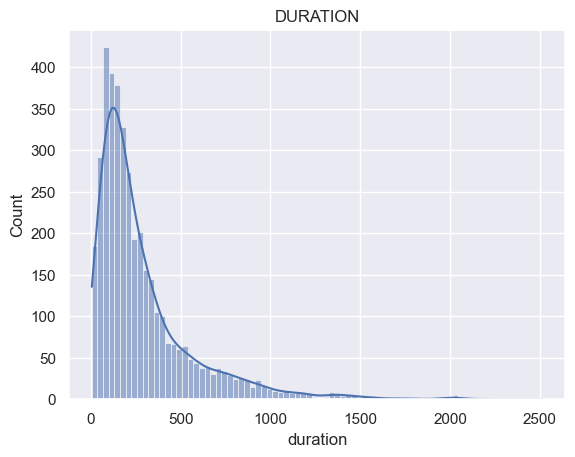

Min CAMPAIGN is: 1
Max CAMPAIGN is: 51
Mean CAMPAIGN is: 2.71875
Standard deviation of CAMPAIGN is: 3.05


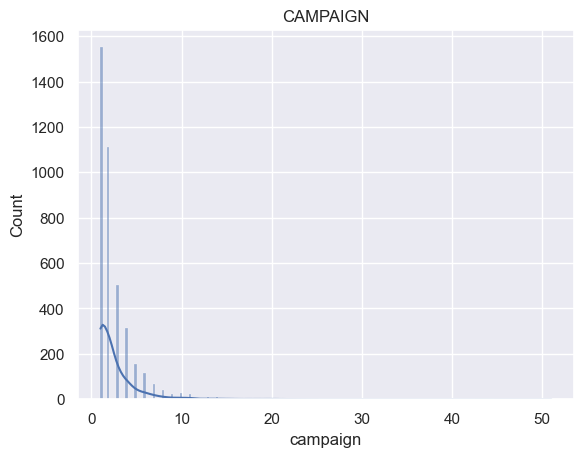

Min PDAYS is: -1
Max PDAYS is: 831
Mean PDAYS is: 43.1185
Standard deviation of PDAYS is: 102.75


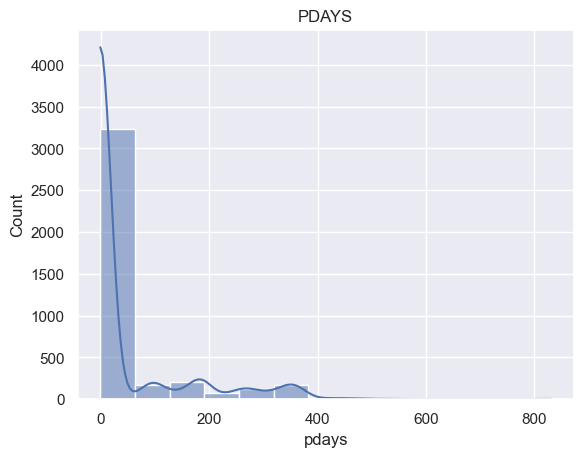

Min PREVIOUS is: 0
Max PREVIOUS is: 58
Mean PREVIOUS is: 0.64875
Standard deviation of PREVIOUS is: 2.08


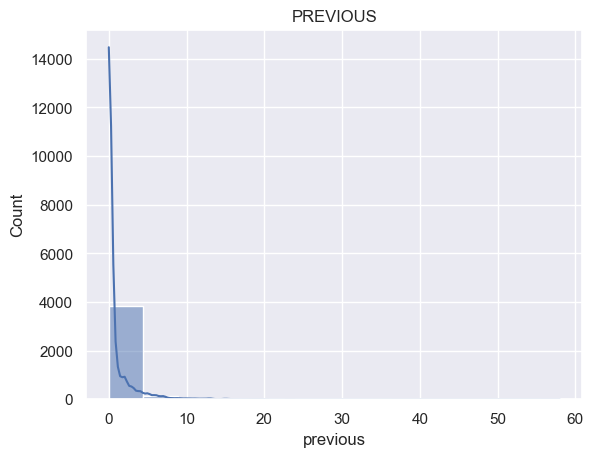

In [911]:
for col in model_data.select_dtypes('int64').columns.to_list():
    print("Min {} is:".format(col.upper()),np.min(model_data[col]))
    print("Max {} is:".format(col.upper()),np.max(model_data[col]))
    print("Mean {} is:".format(col.upper()),np.mean(model_data[col]))
    print("Standard deviation of {} is: {:.2f}".format(col.upper(),np.std(model_data[col])))
    plt.title(col.upper())
    sns.histplot(model_data[col],kde=True)
    plt.show()

#### Statistical summary of dataset

In [ ]:
model_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4000.0,41.08650,10.770679,18.0,33.0,39.0,49.0,95.0
balance,4000.0,1431.79625,2935.849718,-1884.0,78.0,478.0,1545.5,42045.0
day,4000.0,15.64200,8.267613,1.0,8.0,16.0,21.0,31.0
duration,4000.0,288.96475,285.210796,5.0,108.0,193.5,358.0,2516.0
campaign,4000.0,2.71875,3.051471,1.0,1.0,2.0,3.0,51.0
pdays,4000.0,43.11850,102.765097,-1.0,-1.0,-1.0,-1.0,831.0
previous,4000.0,0.64875,2.080614,0.0,0.0,0.0,0.0,58.0


#### Pair plot of all the numerical columns of the data with target column as hue.

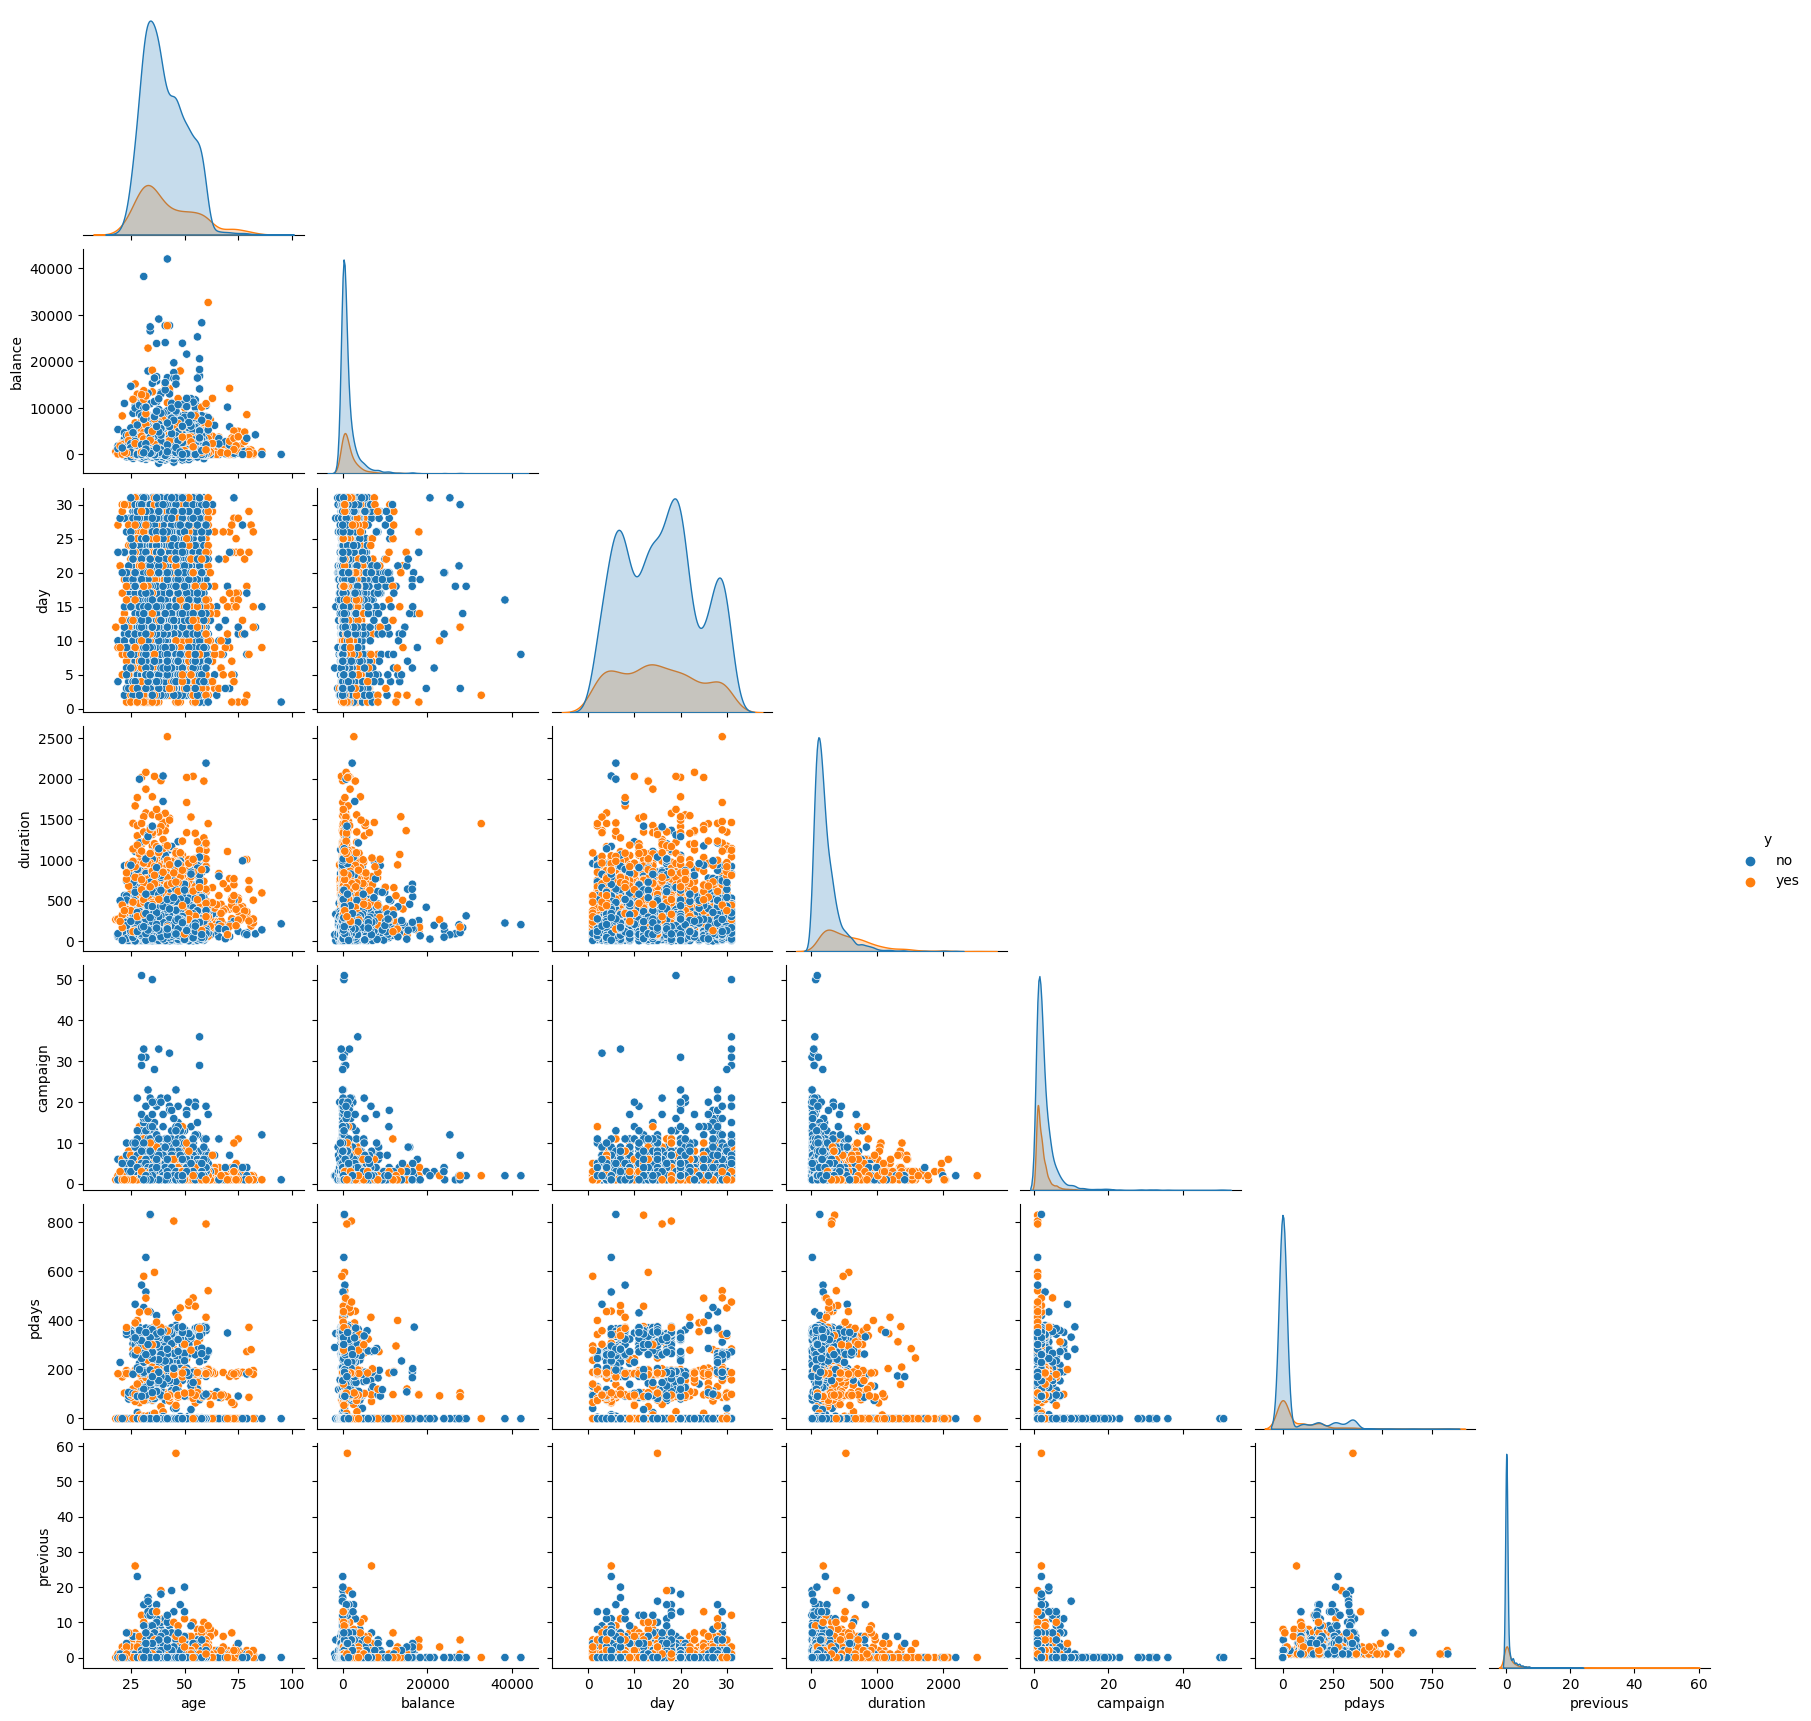

In [7]:
sns.pairplot(model_data,hue='y',corner=True)

#### A correlation coefficient heatmap of all numerical columns in our dataset.

<AxesSubplot: >

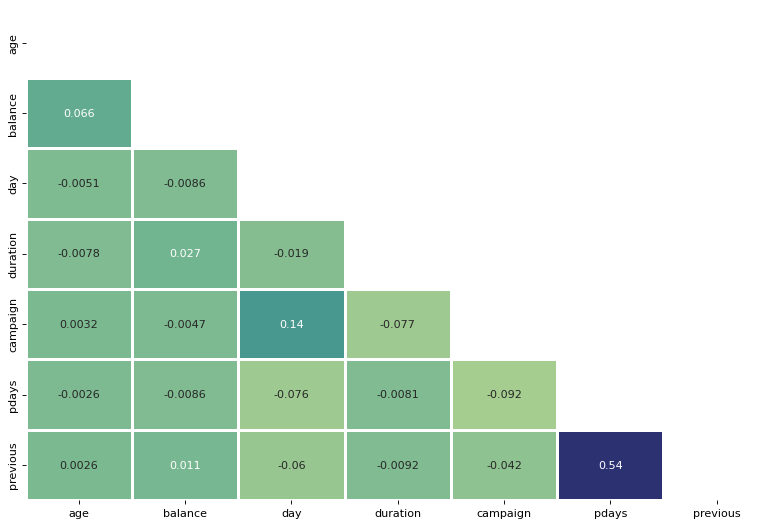

In [63]:
plt.figure(figsize=(12,8),dpi=80)
sns.heatmap(model_data.corr(numeric_only=True),cmap='crest',annot=True,linewidth=1,mask=np.triu(model_data.corr(numeric_only=True)),cbar=False)

### Inferencing

From the chart below, people having management job are more likely to be interested in our product.

<AxesSubplot: xlabel='count', ylabel='job'>

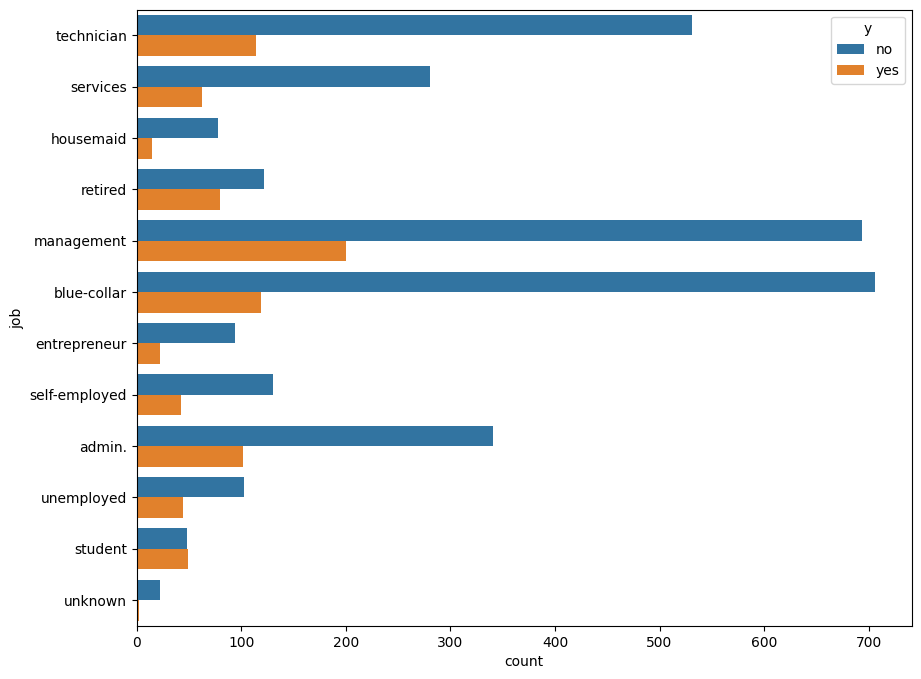

In [9]:
plt.figure(figsize=(10,8))
sns.countplot(model_data,y='job',hue='y')

Do people with a management job have higher bank balance? because higher bank balance might result in a deposit.

It turns out that people with management job indeed have a higher bank balance and thus resulting in a deposit.

              job  balance
0          admin.   513849
1     blue-collar   869722
2    entrepreneur   185842
3       housemaid   156949
4      management  1656268
5         retired   326017
6   self-employed   344592
7        services   351045
8         student   155558
9      technician   931326
10     unemployed   188042
11        unknown    47975


<AxesSubplot: xlabel='balance', ylabel='job'>

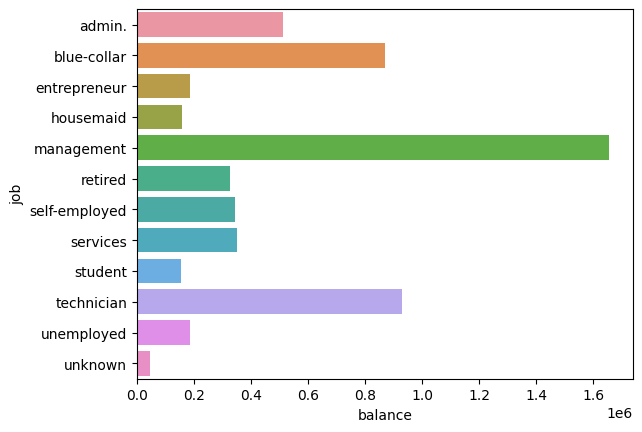

In [10]:
job_balance=model_data.groupby('job')['balance'].sum()
job_balance=job_balance.reset_index()
print(job_balance)
sns.barplot(x='balance',y='job',data=job_balance)

#### What affects the balance and successful deposit

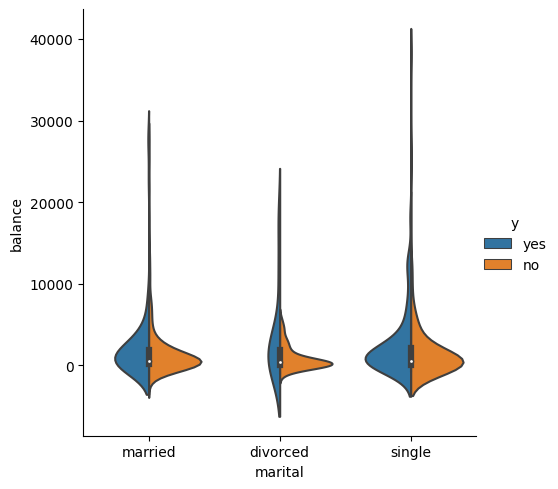

In [11]:
management_job=model_data[model_data.job=='management']
sns.catplot(management_job,y='balance',x='marital',hue='y',kind='violin',split=True)

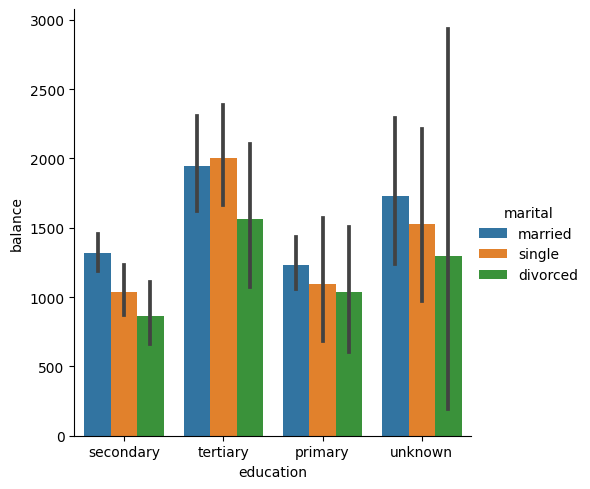

In [67]:
#impact of marital status and education level on deposit
sns.catplot(model_data,y='balance',x='education',hue='marital',kind='bar')

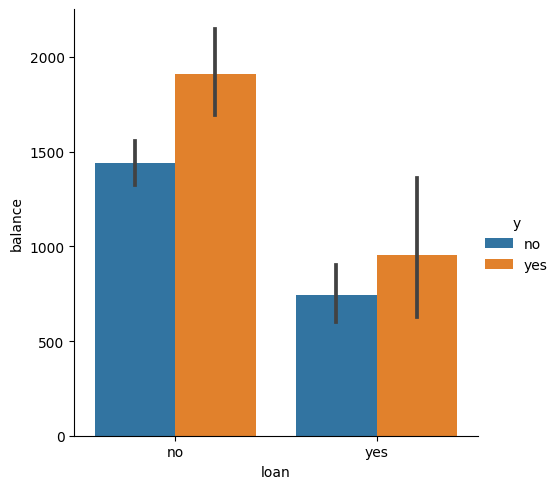

In [71]:
#impact of loan on balance and deposit
sns.catplot(model_data,x='loan',y='balance',hue='y',kind='bar')

### Preparing data for feature evaluation

In [74]:
l_encoder_columns=['default','housing','loan','y']
one_hot_encoder_columns=['job','marital','education','contact','poutcome']
int_columns=model_data.select_dtypes('int64').columns.to_list()
data_encoded=model_data.loc[:,int_columns+l_encoder_columns]

In [75]:
#label encoder
le=LabelEncoder()
for col in l_encoder_columns:
    data_encoded[col]=le.fit_transform(data_encoded[col])

print(data_encoded.shape)
print(data_encoded.head(5))

(4000, 11)
   age  balance  day  duration  campaign  pdays  previous  default  housing  \
0   42       27   14       259         4     -1         0        0        0   
1   28      230   17       181         2     -1         0        0        1   
2   52     4306   22       107         2     -1         0        0        0   
3   70       44   18      1104         2     88         2        0        0   
4   50      313   14       958         1     -1         0        0        0   

   loan  y  
0     0  0  
1     1  0  
2     0  0  
3     0  1  
4     0  1  


In [76]:
#one-hot encoder
onehot_en=OneHotEncoder(dtype=int,drop='first')
one_hot_encoded=onehot_en.fit_transform(model_data[one_hot_encoder_columns])
one_hot_encoded=one_hot_encoded.toarray()
one_hot_encoded=pd.DataFrame(one_hot_encoded,columns=onehot_en.get_feature_names_out(one_hot_encoder_columns))

print(one_hot_encoded.head(5))

   job_blue-collar  job_entrepreneur  job_housemaid  job_management  \
0                0                 0              0               0   
1                0                 0              0               0   
2                0                 0              1               0   
3                0                 0              0               0   
4                0                 0              0               1   

   job_retired  job_self-employed  job_services  job_student  job_technician  \
0            0                  0             0            0               1   
1            0                  0             1            0               0   
2            0                  0             0            0               0   
3            1                  0             0            0               0   
4            0                  0             0            0               0   

   job_unemployed  ...  marital_married  marital_single  education_secondary  \
0           

In [77]:
#final encoded dataset
data_encoded=pd.concat([data_encoded,one_hot_encoded],axis=1)
data_encoded.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'default', 'housing', 'loan', 'y', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'contact_telephone', 'contact_unknown', 'poutcome_other',
       'poutcome_success', 'poutcome_unknown'],
      dtype='object')

In [78]:
#splitting the features and target class
X=data_encoded.drop(['duration','y'],axis=1)
Y=data_encoded[['y']]

In [79]:
#scaling the dataset
scaler = MinMaxScaler()
scaled_X=scaler.fit_transform(X)

In [80]:
#setup the parameters for grid search
test_param = {'criterion': ['gini', 'entropy'],  #scoring methodology; two supported parameters for calculating information gain - default is gini
              'splitter': ['best', 'random'], #splitting methodology; two supported strategies - default is best
              'max_depth': [2,3,4,5,6,8,10,None], #default is none
              'min_samples_split': [2,5,10,.03,.05], #minimum subset size BEFORE new split; default is 2
              'min_samples_leaf': [1,5,10,.03,.05], #minimum subset size AFTER new split split; default is 1
              'max_features': [None, 'sqrt'], #max features to consider when performing split; default none or all
              'random_state': [0] #seed
             }

In [927]:
#find the best parameters for Decision tree
best_param_search=GridSearchCV(DecisionTreeClassifier(),param_grid=test_param,scoring='roc_auc',cv=5,verbose=0)
best_param_search.fit(scaled_X,Y)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
                         'max_features': [None, 'sqrt'],
                         'min_samples_leaf': [1, 5, 10, 0.03, 0.05],
                         'min_samples_split': [2, 5, 10, 0.03, 0.05],
                         'random_state': [0], 'splitter': ['best', 'random']},
             scoring='roc_auc')

In [928]:
#best parameters of decision tree
best_param_search.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 5,
 'min_samples_split': 0.05,
 'random_state': 0,
 'splitter': 'random'}

In [81]:
#decision tree classifier
dt=DecisionTreeClassifier(min_samples_split=0.05,min_samples_leaf=5,criterion='entropy',random_state=0,max_depth=10)

In [82]:
#fit the train dataset to decision tree classifier
dt.fit(scaled_X,Y)
pred = dt.predict(scaled_X)


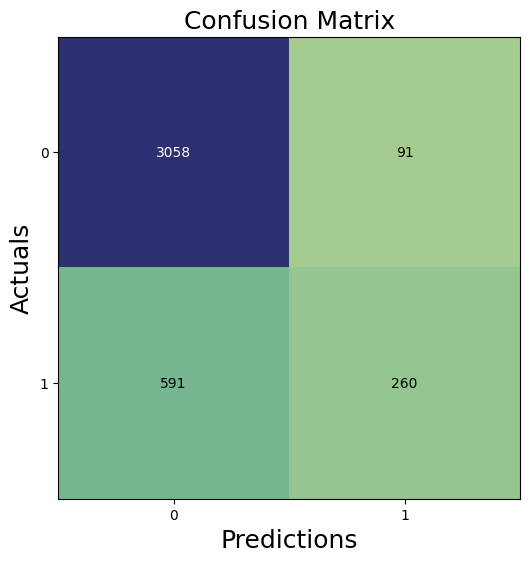

In [89]:
#confusion matrix of decision tree
cm=confusion_matrix(Y,pred,labels=dt.classes_)
 
fig, ax = plot_confusion_matrix(conf_mat=cm, figsize=(6, 6), cmap='crest',colorbar=False)
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

In [84]:
#cross-validation definition
def cross_validation(model, X_input, Y_input, cv_fold=5):
    scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
    results = cross_validate(estimator=model,X=X_input,y=Y_input,cv=cv_fold,scoring=scoring_metrics,return_train_score=True)
    return {
        "Training Accuracy scores": results['train_accuracy'],
            "Mean Training Accuracy": results['train_accuracy'].mean()*100,
            "Training Precision scores": results['train_precision'],
            "Mean Training Precision": results['train_precision'].mean(),
            "Training Recall scores": results['train_recall'],
            "Mean Training Recall": results['train_recall'].mean(),
            "Training F1 scores": results['train_f1'],
            "Mean Training F1 Score": results['train_f1'].mean(),
            "Validation Accuracy scores": results['test_accuracy'],
            "Mean Validation Accuracy": results['test_accuracy'].mean()*100,
            "Validation Precision scores": results['test_precision'],
            "Mean Validation Precision": results['test_precision'].mean(),
            "Validation Recall scores": results['test_recall'],
            "Mean Validation Recall": results['test_recall'].mean(),
            "Validation F1 scores": results['test_f1'],
            "Mean Validation F1 Score": results['test_f1'].mean()  
    }

In [85]:
#decision tree cross-validation results
decision_tree_result = cross_validation(dt, X, Y, 5)
print(decision_tree_result)

{'Training Accuracy scores': array([0.8303125, 0.8278125, 0.8315625, 0.830625 , 0.8265625]), 'Mean Training Accuracy': 82.9375, 'Training Precision scores': array([0.70294118, 0.68786127, 0.66904762, 0.76833977, 0.7593361 ]), 'Mean Training Precision': 0.7175051870238677, 'Training Recall scores': array([0.35095448, 0.34948605, 0.41262849, 0.29221733, 0.26911765]), 'Mean Training Recall': 0.33488079813423166, 'Training F1 scores': array([0.46816846, 0.46348588, 0.51044505, 0.42340426, 0.39739414]), 'Mean Training F1 Score': 0.4525795571161648, 'Validation Accuracy scores': array([0.82   , 0.81   , 0.815  , 0.81875, 0.80625]), 'Mean Validation Accuracy': 81.4, 'Validation Precision scores': array([0.64444444, 0.60227273, 0.625     , 0.63736264, 0.63793103]), 'Mean Validation Precision': 0.6294021687125136, 'Validation Recall scores': array([0.34117647, 0.31176471, 0.32352941, 0.34117647, 0.21637427]), 'Mean Validation Recall': 0.3068042655658755, 'Validation F1 scores': array([0.4461538

In [32]:
#plotting diffrent cross-validation measures.
def plot_result(x_label, y_label, plot_title, train_data, val_data):
    plt.figure(figsize=(12,6))
    labels = ["1st Fold", "2nd Fold", "3rd Fold", "4th Fold", "5th Fold"]
    X_axis = np.arange(len(labels))
    ax = plt.gca()
    plt.ylim(0.10000, 1)
    plt.bar(X_axis-0.2, train_data, 0.4, color='blue', label='Training')
    plt.bar(X_axis+0.2, val_data, 0.4, color='red', label='Validation')
    plt.title(plot_title, fontsize=30)
    plt.xticks(X_axis, labels)
    plt.xlabel(x_label, fontsize=14)
    plt.ylabel(y_label, fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.show()

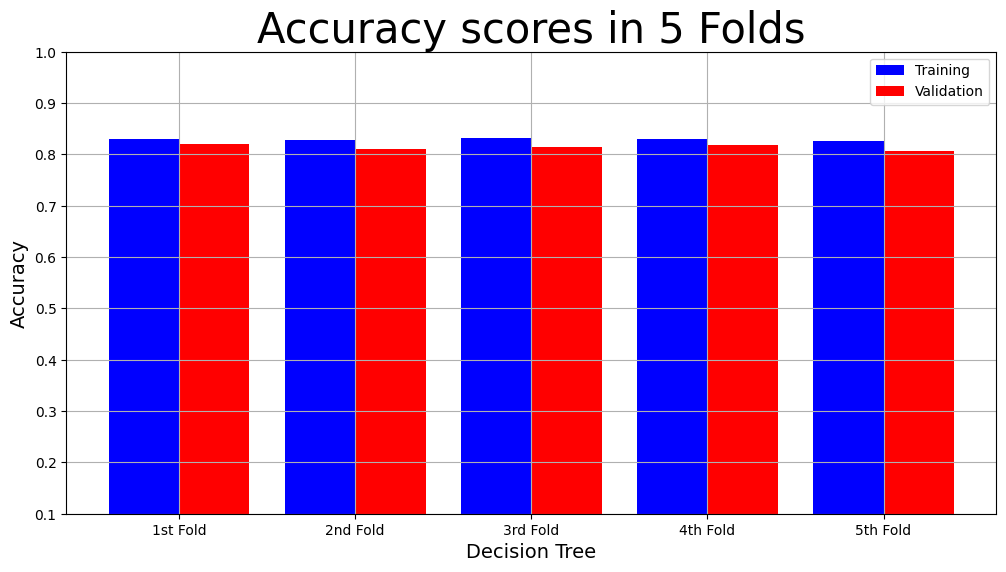

In [33]:
model_name = "Decision Tree"
plot_result(model_name,
            "Accuracy",
            "Accuracy scores in 5 Folds",
            decision_tree_result["Training Accuracy scores"],
            decision_tree_result["Validation Accuracy scores"])

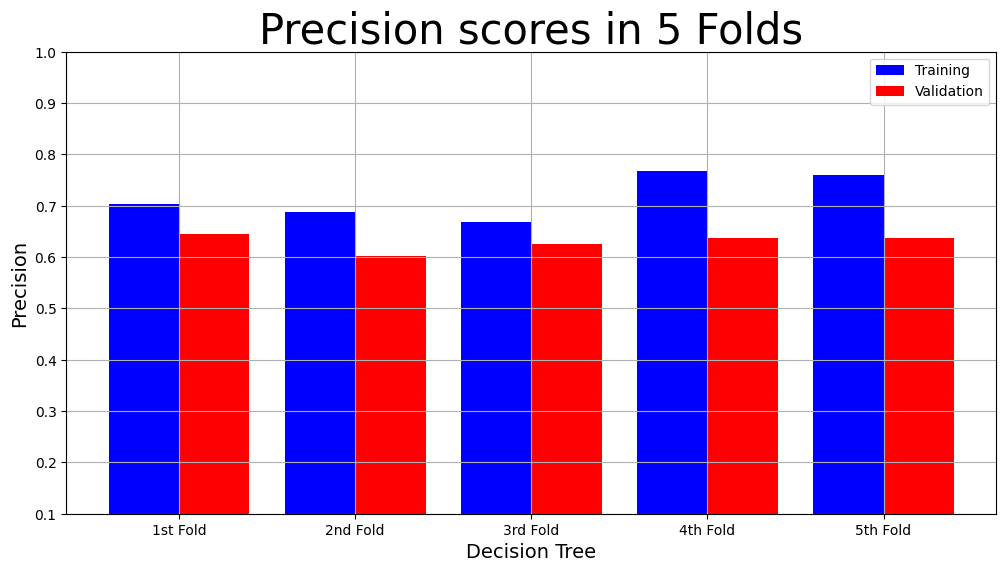

In [34]:
plot_result(model_name,
            "Precision",
            "Precision scores in 5 Folds",
            decision_tree_result["Training Precision scores"],
            decision_tree_result["Validation Precision scores"])

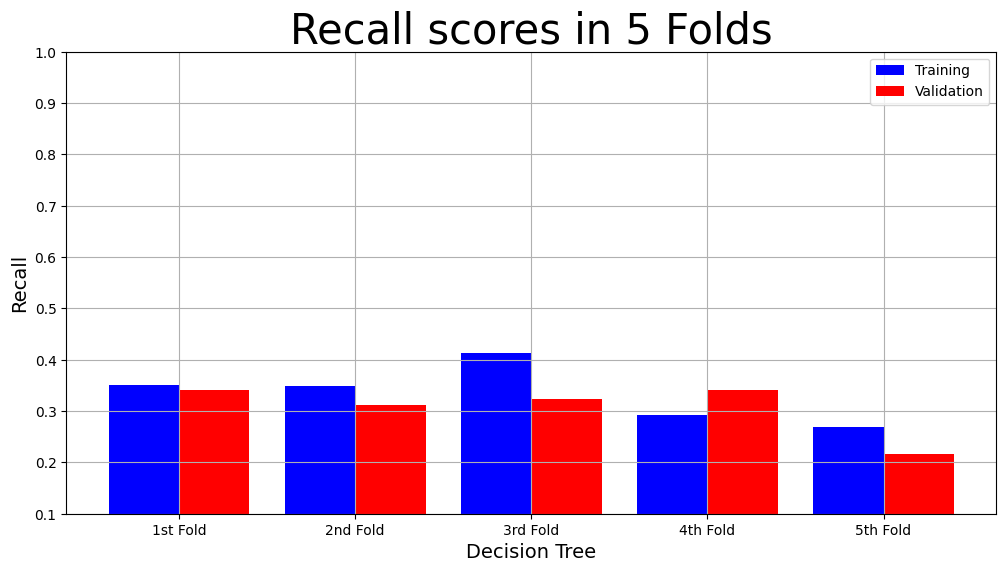

In [35]:
plot_result(model_name,
            "Recall",
            "Recall scores in 5 Folds",
            decision_tree_result["Training Recall scores"],
            decision_tree_result["Validation Recall scores"])

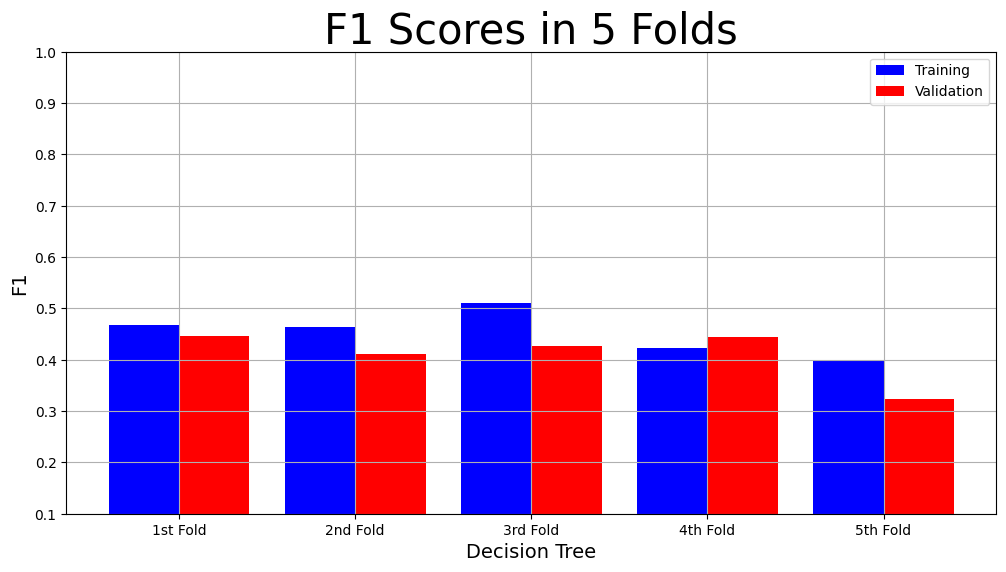

In [36]:
plot_result(model_name,
            "F1",
            "F1 Scores in 5 Folds",
            decision_tree_result["Training F1 scores"],
            decision_tree_result["Validation F1 scores"])

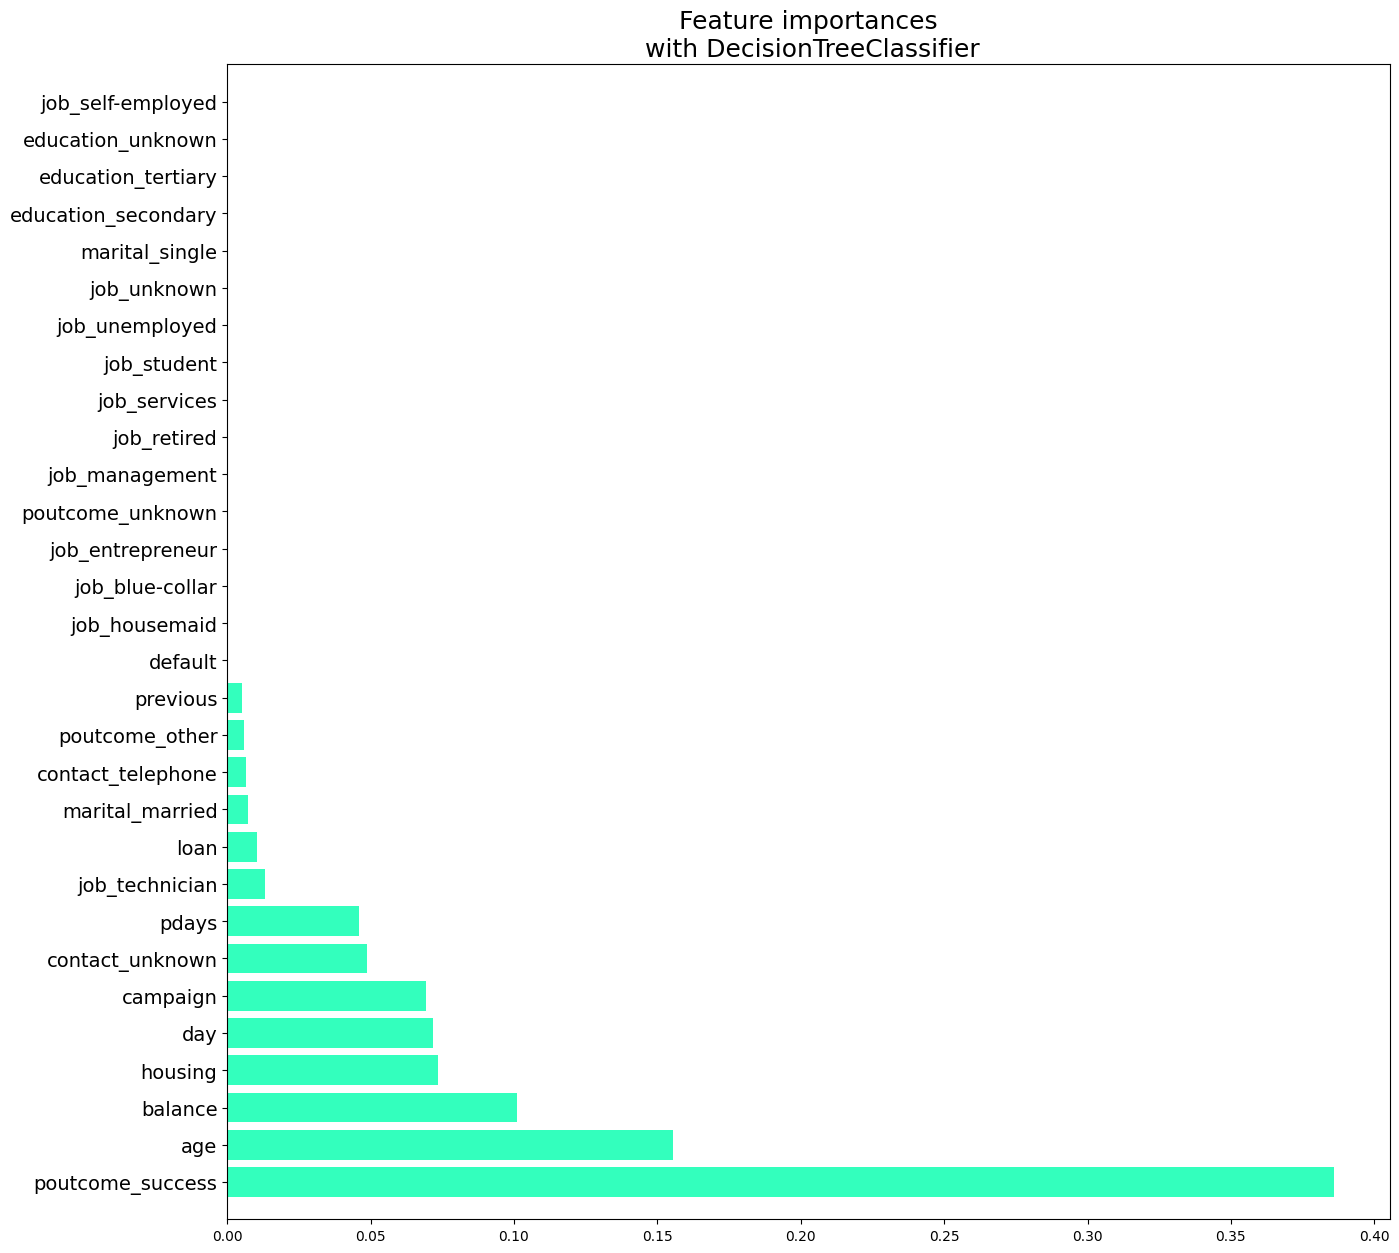

In [86]:
#important features plot
importances = dt.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot the feature importances of the forest
def feature_importance(indices, importances, feature_names):
    plt.figure(figsize=(15,15))
    plt.title(" Feature importances \n with DecisionTreeClassifier", fontsize=18)
    plt.barh(range(len(indices)), importances[indices], color='#33FFBD',  align="center")
    plt.yticks(range(len(indices)), feature_names[indices], rotation='horizontal',fontsize=14)
    plt.ylim([-1, len(indices)])

feature_importance(indices, importances, feature_names)
plt.show()

In [90]:
#importance features measure

feature_importance=dict(zip(feature_names,importances))
#print(feature_importance)
feature_importance=dict(filter(lambda x :x[1]!=0.0,feature_importance.items()))
feature_importance=dict(sorted(feature_importance.items(),key=lambda x:x[1],reverse=True))
print(feature_importance)

{'poutcome_success': 0.3860724345000413, 'age': 0.1552885899609503, 'balance': 0.10094319301344064, 'housing': 0.07352138223924826, 'day': 0.07177647438872008, 'campaign': 0.06946744631016127, 'contact_unknown': 0.048845093351659985, 'pdays': 0.0460077667932921, 'job_technician': 0.013182543971419483, 'loan': 0.010376100110199092, 'marital_married': 0.007172807227277618, 'contact_telephone': 0.006437761215949128, 'poutcome_other': 0.005741414573046385, 'previous': 0.005166992344594294}


In [91]:
#export these important feature tables a pickle file to train other ML models.
important_features=list(feature_importance.keys())
important_features_data=data_encoded.loc[:,important_features+['y']]
important_features_data.columns
important_features_data.to_pickle('selected_features.pkl')

[Text(0.6666666666666666, 0.875, 'poutcome_success <= 0.5\nentropy = 0.747\nsamples = 4000\nvalue = [3149, 851]\nclass = yes'),
 Text(0.5, 0.625, 'age <= 0.552\nentropy = 0.686\nsamples = 3810\nvalue = [3113, 697]\nclass = yes'),
 Text(0.3333333333333333, 0.375, 'housing <= 0.5\nentropy = 0.662\nsamples = 3717\nvalue = [3078, 639]\nclass = yes'),
 Text(0.16666666666666666, 0.125, '\n  (...)  \n'),
 Text(0.5, 0.125, '\n  (...)  \n'),
 Text(0.6666666666666666, 0.375, 'entropy = 0.955\nsamples = 93\nvalue = [35, 58]\nclass = no'),
 Text(0.8333333333333334, 0.625, 'entropy = 0.7\nsamples = 190\nvalue = [36, 154]\nclass = no')]

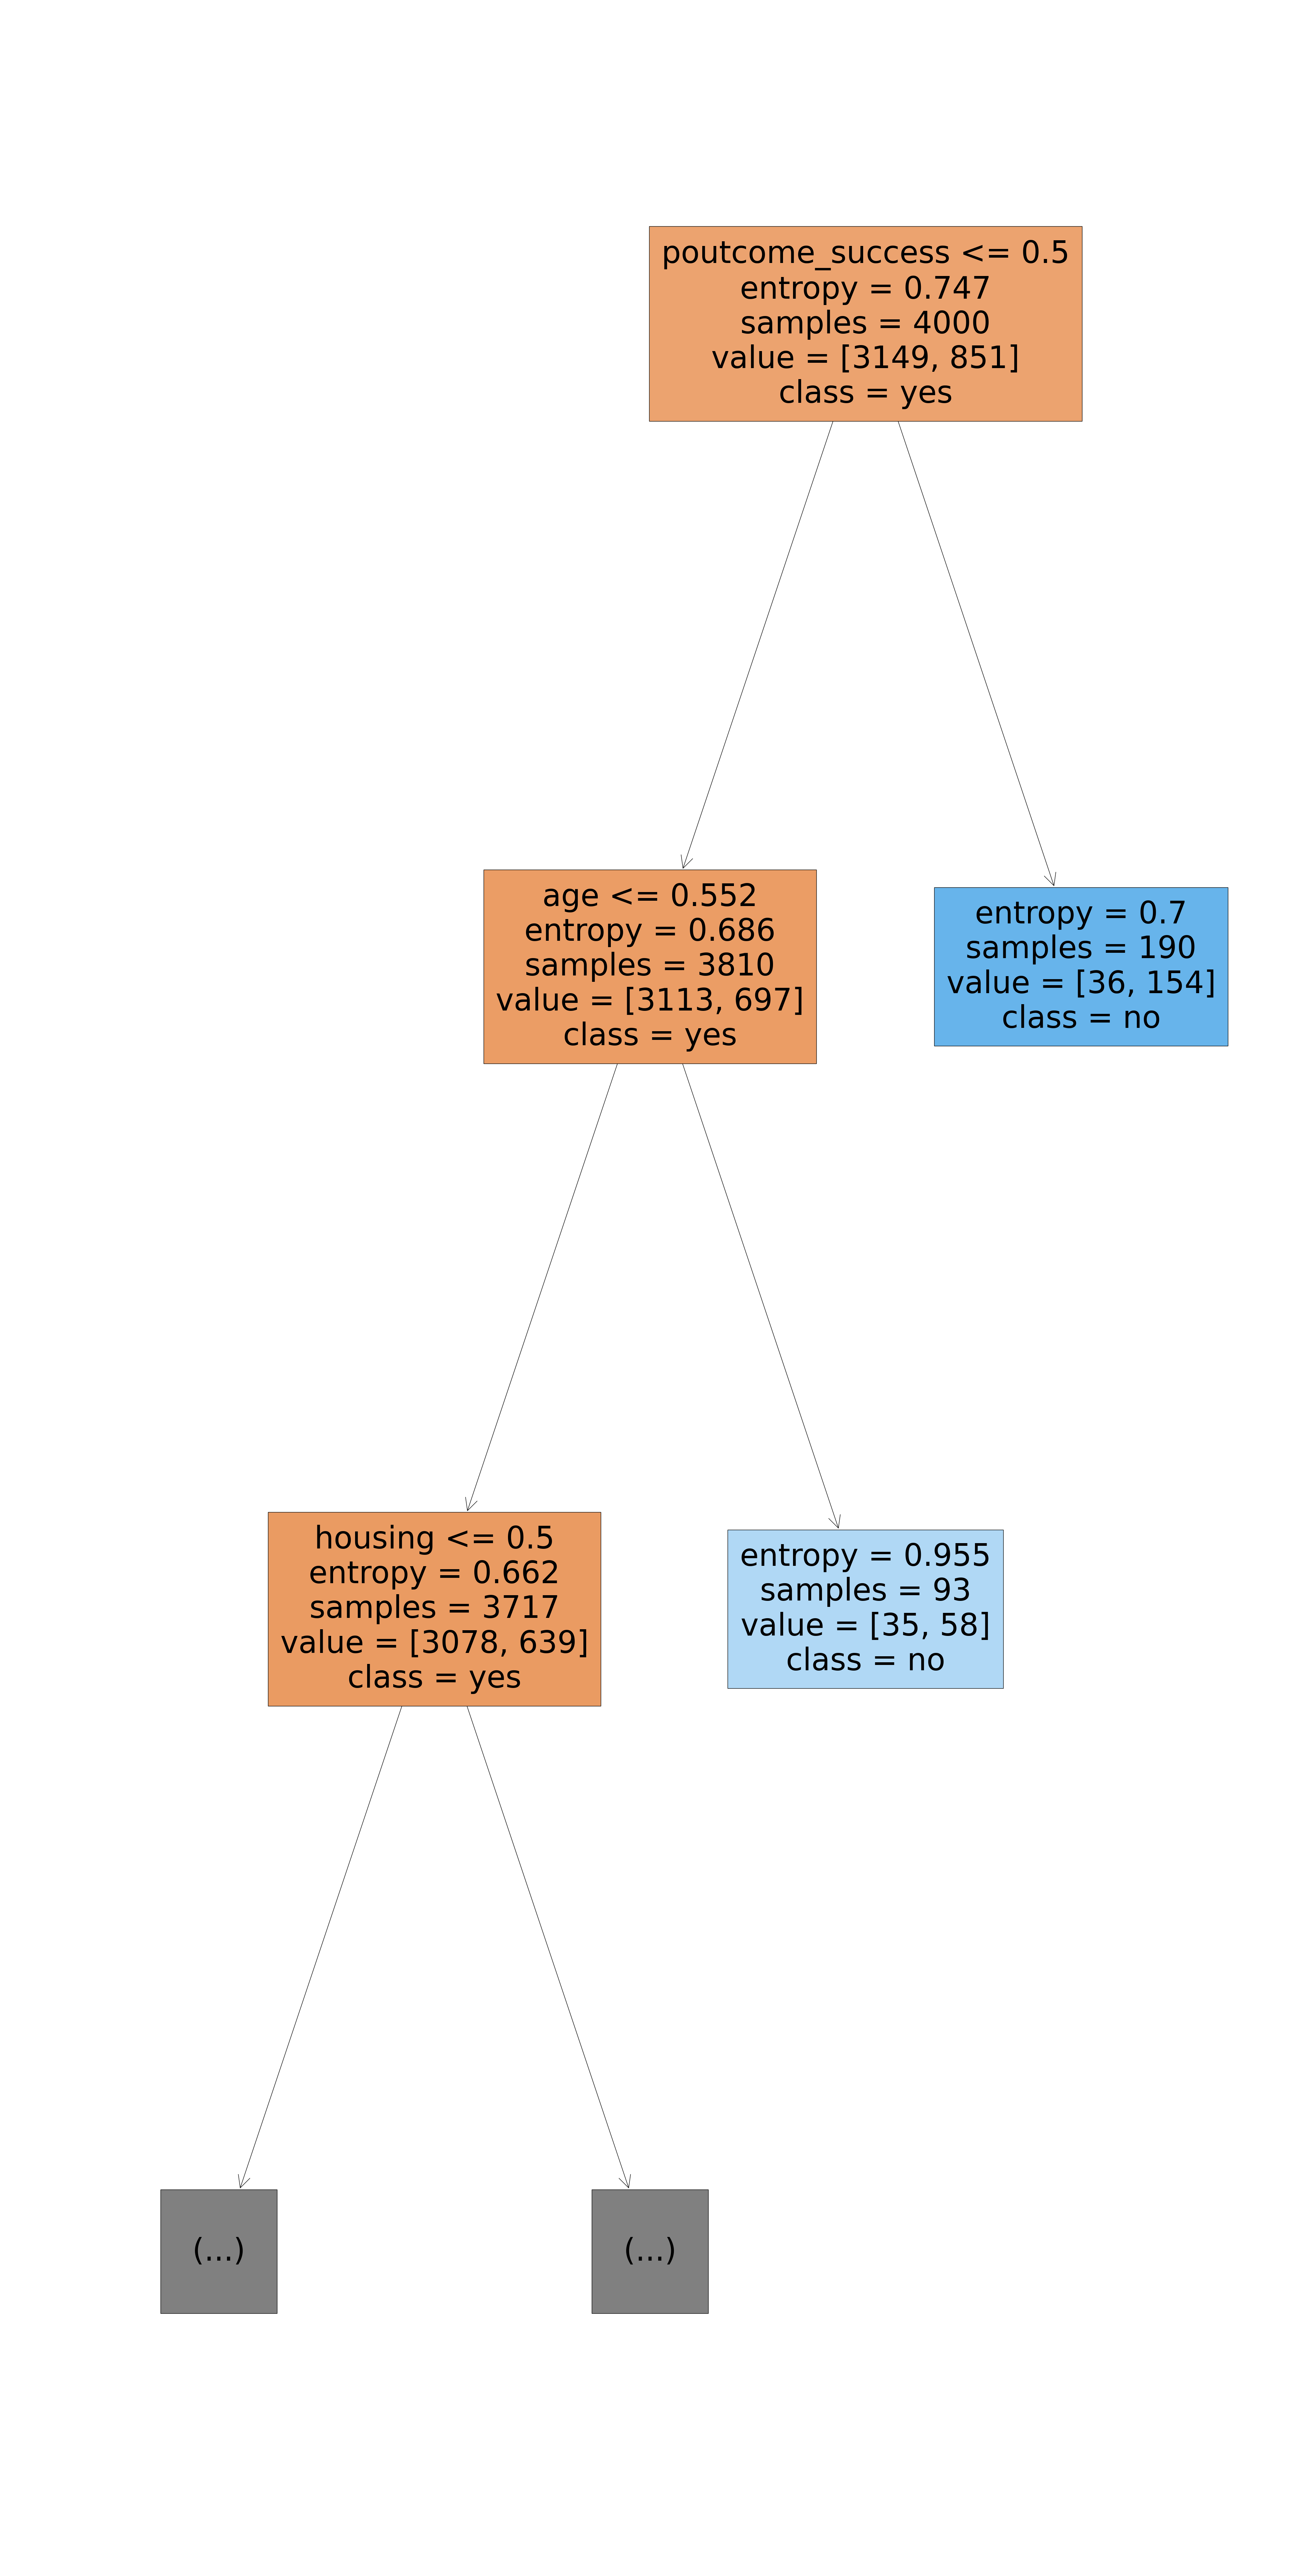

In [113]:
#decision tree
from sklearn import tree
plt.figure(figsize=(50,100))
tree.plot_tree(dt,filled=True,feature_names=feature_names,class_names= ['yes','no'],max_depth=2)